# Data Science Bowl 2018 — EDA
Cell nucleus segmentation dataset: 670 training samples, 65 test samples.

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import seaborn as sns
from PIL import Image
from skimage import color, exposure
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid", palette="muted")
random.seed(42)
np.random.seed(42)

In [6]:
DATA_ROOT = Path("data-science-bowl-2018")
TRAIN_DIR = DATA_ROOT / "stage1_train"
TEST_DIR  = DATA_ROOT / "stage1_test"
SOLUTION_CSV = DATA_ROOT / "stage1_solution.csv" / "stage1_solution.csv"

train_ids = sorted(os.listdir(TRAIN_DIR))
test_ids  = sorted(os.listdir(TEST_DIR))
print(f"Train samples : {len(train_ids)}")
print(f"Test  samples : {len(test_ids)}")

Train samples : 670
Test  samples : 65


## 1. Dataset Overview

In [7]:
solution = pd.read_csv(SOLUTION_CSV)
print(solution.shape)
solution.head()

(4152, 5)


,ImageId,EncodedPixels,Height,Width,Usage
0,0114f484a16c152baa2d82fdd43740880a762c93f436c8...,31632 6 31886 10 32139 14 32394 15 32649 17 32...,256,256,Public
1,0114f484a16c152baa2d82fdd43740880a762c93f436c8...,50280 7 50534 10 50788 13 51043 14 51298 16 51...,256,256,Public
2,0114f484a16c152baa2d82fdd43740880a762c93f436c8...,10892 5 11146 9 11401 10 11656 11 11911 13 121...,256,256,Public
3,0114f484a16c152baa2d82fdd43740880a762c93f436c8...,45104 8 45359 10 45614 12 45869 14 46124 15 46...,256,256,Public
4,0114f484a16c152baa2d82fdd43740880a762c93f436c8...,38564 4 38819 6 39074 8 39327 11 39582 12 3983...,256,256,Public


In [8]:
print("Usage split:")
print(solution.drop_duplicates("ImageId")["Usage"].value_counts())

Usage split:
Usage
Public    65
Name: count, dtype: int64


## 2. Image Size Distribution

In [9]:
records = []
for tid in tqdm(train_ids, desc="Reading train metadata"):
    img_path = next((TRAIN_DIR / tid / "images").glob("*.png"))
    with Image.open(img_path) as img:
        w, h = img.size
        mode = img.mode
    n_masks = len(list((TRAIN_DIR / tid / "masks").glob("*.png")))
    records.append({"id": tid, "width": w, "height": h, "mode": mode, "n_nuclei": n_masks})

df = pd.DataFrame(records)
df.head()

Reading train metadata:   0%|          | 0/670 [00:00<?, ?it/s]

,id,width,height,mode,n_nuclei
0,00071198d059ba7f5914a526d124d28e6d010c92466da2...,256,256,RGBA,27
1,003cee89357d9fe13516167fd67b609a164651b2193458...,256,256,RGBA,36
2,00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b074...,320,256,RGBA,70
3,0121d6759c5adb290c8e828fc882f37dfaf3663ec885c6...,320,256,RGBA,86
4,01d44a26f6680c42ba94c9bc6339228579a95d0e2695b1...,320,256,RGBA,7


In [10]:
print(df[["width", "height", "n_nuclei"]].describe().round(1))

        width  height  n_nuclei
count   670.0   670.0     670.0
mean    378.5   334.0      44.0
std     204.8   149.5      48.0
min     256.0   256.0       1.0
25%     256.0   256.0      15.2
50%     320.0   256.0      27.0
75%     360.0   360.0      54.0
max    1388.0  1040.0     375.0


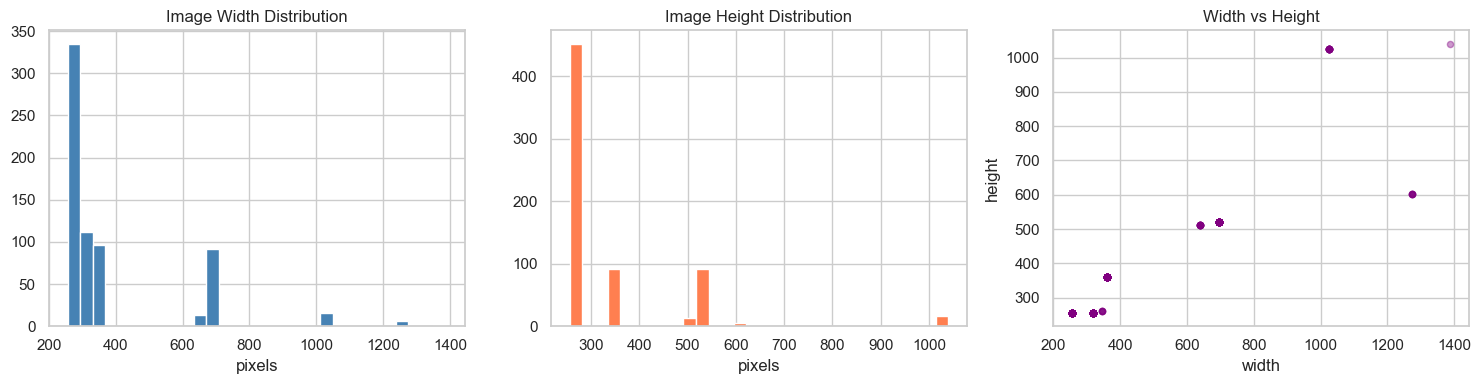

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["width"],  bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Image Width Distribution");  axes[0].set_xlabel("pixels")

axes[1].hist(df["height"], bins=30, color="coral",    edgecolor="white")
axes[1].set_title("Image Height Distribution"); axes[1].set_xlabel("pixels")

axes[2].scatter(df["width"], df["height"], alpha=0.4, s=20, color="purple")
axes[2].set_title("Width vs Height"); axes[2].set_xlabel("width"); axes[2].set_ylabel("height")

plt.tight_layout()
plt.show()

In [12]:
print("Unique (width, height) pairs:", df.groupby(["width", "height"]).ngroups)
print("\nTop 10 most common sizes:")
print(df.groupby(["width", "height"]).size().sort_values(ascending=False).head(10))

Unique (width, height) pairs: 9

Top 10 most common sizes:
width  height
256    256       334
320    256       112
696    520        92
360    360        91
1024   1024       16
640    512        13
1272   603         6
347    260         5
1388   1040        1
dtype: int64


## 3. Channel / Color Mode

mode
RGBA    670
Name: count, dtype: int64


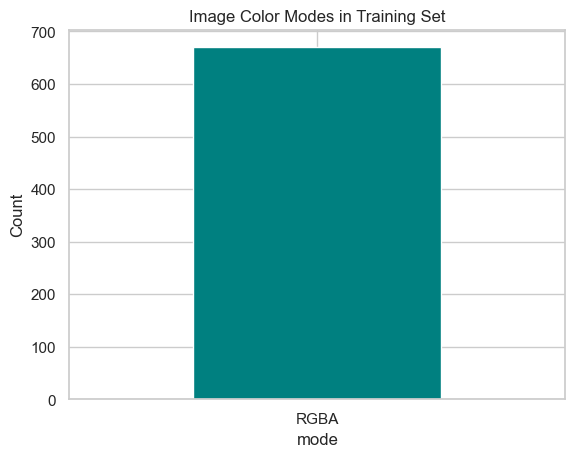

In [13]:
mode_counts = df["mode"].value_counts()
print(mode_counts)

mode_counts.plot(kind="bar", color="teal", edgecolor="white", rot=0)
plt.title("Image Color Modes in Training Set")
plt.ylabel("Count")
plt.show()

## 4. Nucleus Count Distribution

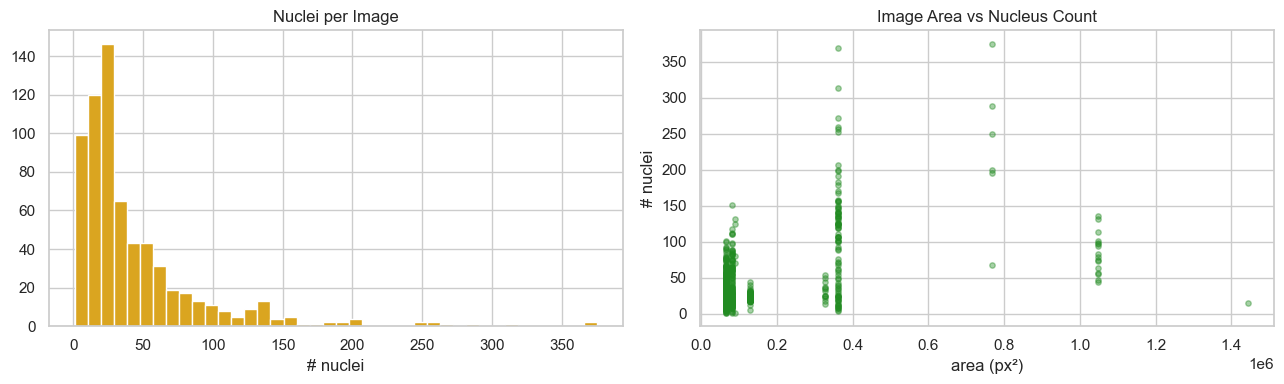

count    670.0
mean      44.0
std       48.0
min        1.0
25%       15.2
50%       27.0
75%       54.0
max      375.0
Name: n_nuclei, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["n_nuclei"], bins=40, color="goldenrod", edgecolor="white")
axes[0].set_title("Nuclei per Image")
axes[0].set_xlabel("# nuclei")

axes[1].scatter(df["width"] * df["height"], df["n_nuclei"], alpha=0.4, s=15, color="forestgreen")
axes[1].set_title("Image Area vs Nucleus Count")
axes[1].set_xlabel("area (px²)"); axes[1].set_ylabel("# nuclei")

plt.tight_layout()
plt.show()

print(df["n_nuclei"].describe().round(1))

## 5. Sample Images with Overlaid Masks

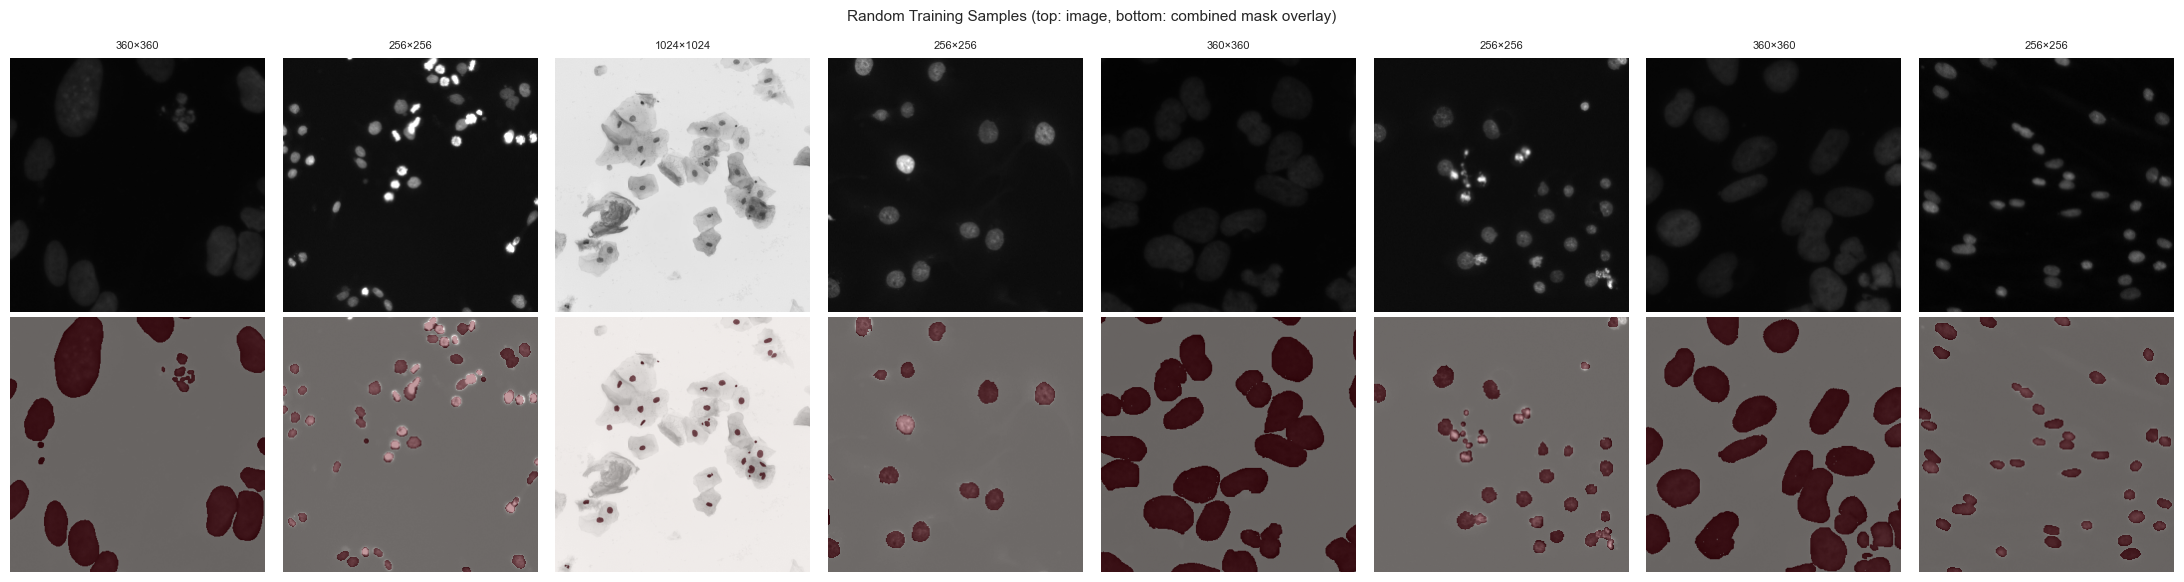

In [15]:
def load_masks_combined(sample_id, split_dir):
    mask_dir = split_dir / sample_id / "masks"
    masks = [np.array(Image.open(p).convert("L")) for p in mask_dir.glob("*.png")]
    if not masks:
        return None
    combined = np.zeros_like(masks[0], dtype=np.uint8)
    for m in masks:
        combined = np.maximum(combined, m)
    return combined

sample_ids = random.sample(train_ids, 8)
fig, axes = plt.subplots(2, 8, figsize=(22, 6))

for i, sid in enumerate(sample_ids):
    img = np.array(Image.open(next((TRAIN_DIR / sid / "images").glob("*.png"))).convert("RGB"))
    mask = load_masks_combined(sid, TRAIN_DIR)

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"{img.shape[0]}×{img.shape[1]}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(img)
    if mask is not None:
        axes[1, i].imshow(mask, alpha=0.4, cmap="Reds")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Image",  fontsize=9)
axes[1, 0].set_ylabel("+ Mask", fontsize=9)
plt.suptitle("Random Training Samples (top: image, bottom: combined mask overlay)", fontsize=11)
plt.tight_layout()
plt.show()

## 6. Individual Nucleus Masks

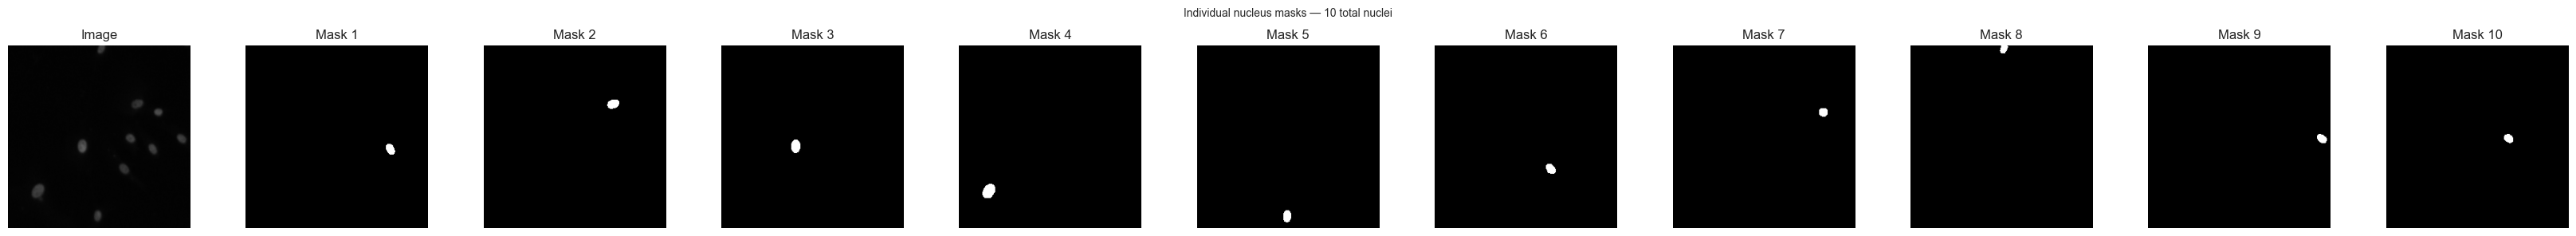

In [16]:
sid = random.choice(train_ids)
mask_paths = list((TRAIN_DIR / sid / "masks").glob("*.png"))
img = np.array(Image.open(next((TRAIN_DIR / sid / "images").glob("*.png"))).convert("RGB"))

n_show = min(10, len(mask_paths))
fig, axes = plt.subplots(1, n_show + 1, figsize=(3 * (n_show + 1), 3))

axes[0].imshow(img); axes[0].set_title("Image"); axes[0].axis("off")
for j, mp in enumerate(mask_paths[:n_show]):
    axes[j + 1].imshow(np.array(Image.open(mp).convert("L")), cmap="gray")
    axes[j + 1].set_title(f"Mask {j+1}"); axes[j + 1].axis("off")

plt.suptitle(f"Individual nucleus masks — {len(mask_paths)} total nuclei", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Pixel Intensity & RGB Channel Statistics

Channel stats:   0%|          | 0/100 [00:00<?, ?it/s]

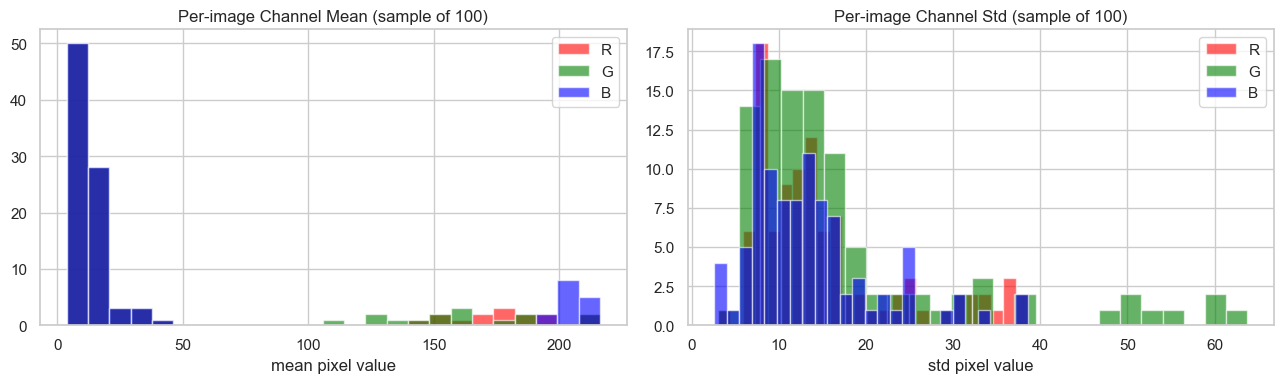

In [17]:
sample_ids_stats = random.sample(train_ids, 100)
means_r, means_g, means_b = [], [], []
stds_r,  stds_g,  stds_b  = [], [], []

for sid in tqdm(sample_ids_stats, desc="Channel stats"):
    arr = np.array(Image.open(next((TRAIN_DIR / sid / "images").glob("*.png"))).convert("RGB"), dtype=float)
    means_r.append(arr[:, :, 0].mean()); means_g.append(arr[:, :, 1].mean()); means_b.append(arr[:, :, 2].mean())
    stds_r.append(arr[:, :, 0].std());   stds_g.append(arr[:, :, 1].std());   stds_b.append(arr[:, :, 2].std())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for vals, label, col in zip([means_r, means_g, means_b], ["R", "G", "B"], ["red", "green", "blue"]):
    axes[0].hist(vals, bins=25, alpha=0.6, label=label, color=col, edgecolor="white")
axes[0].set_title("Per-image Channel Mean (sample of 100)"); axes[0].legend(); axes[0].set_xlabel("mean pixel value")

for vals, label, col in zip([stds_r, stds_g, stds_b], ["R", "G", "B"], ["red", "green", "blue"]):
    axes[1].hist(vals, bins=25, alpha=0.6, label=label, color=col, edgecolor="white")
axes[1].set_title("Per-image Channel Std (sample of 100)"); axes[1].legend(); axes[1].set_xlabel("std pixel value")

plt.tight_layout()
plt.show()

## 8. Grayscale vs Color Images

Gray check:   0%|          | 0/670 [00:00<?, ?it/s]

is_grayscale
True     562
False    108
Name: count, dtype: int64


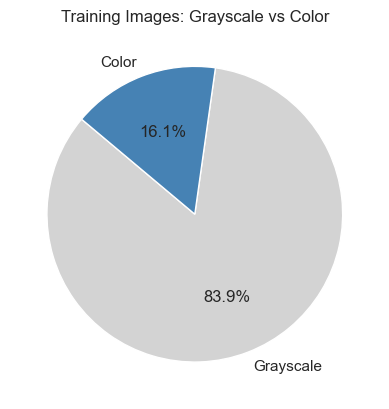

In [18]:
def is_grayscale(arr_rgb):
    """True if R==G==B for all pixels."""
    return np.allclose(arr_rgb[:, :, 0], arr_rgb[:, :, 1]) and np.allclose(arr_rgb[:, :, 1], arr_rgb[:, :, 2])

gray_flags = []
for sid in tqdm(train_ids, desc="Gray check"):
    arr = np.array(Image.open(next((TRAIN_DIR / sid / "images").glob("*.png"))).convert("RGB"))
    gray_flags.append(is_grayscale(arr))

df["is_grayscale"] = gray_flags
print(df["is_grayscale"].value_counts())
df["is_grayscale"].value_counts().rename({True: "Grayscale", False: "Color"}).plot(
    kind="pie", autopct="%1.1f%%", colors=["lightgray", "steelblue"], startangle=140
)
plt.title("Training Images: Grayscale vs Color"); plt.ylabel("")
plt.show()

## 9. Nucleus Size (Mask Area) Distribution

Nucleus areas:   0%|          | 0/80 [00:00<?, ?it/s]

Nucleus area  mean=381  median=247  max=6128


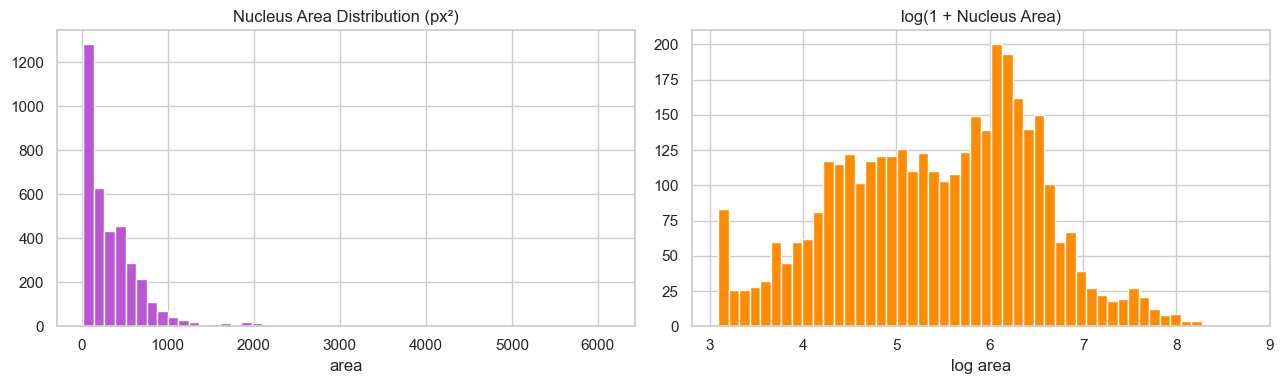

In [19]:
nucleus_areas = []
for sid in tqdm(random.sample(train_ids, 80), desc="Nucleus areas"):
    for mp in (TRAIN_DIR / sid / "masks").glob("*.png"):
        m = np.array(Image.open(mp).convert("L"))
        nucleus_areas.append((m > 0).sum())

nucleus_areas = np.array(nucleus_areas)
print(f"Nucleus area  mean={nucleus_areas.mean():.0f}  median={np.median(nucleus_areas):.0f}  max={nucleus_areas.max()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(nucleus_areas, bins=50, color="mediumorchid", edgecolor="white")
axes[0].set_title("Nucleus Area Distribution (px²)"); axes[0].set_xlabel("area")

axes[1].hist(np.log1p(nucleus_areas), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("log(1 + Nucleus Area)"); axes[1].set_xlabel("log area")

plt.tight_layout()
plt.show()

## 10. Mask Coverage (% of image covered by nuclei)

Mask coverage:   0%|          | 0/670 [00:00<?, ?it/s]

Coverage  mean=13.9%  median=10.7%  max=59.2%


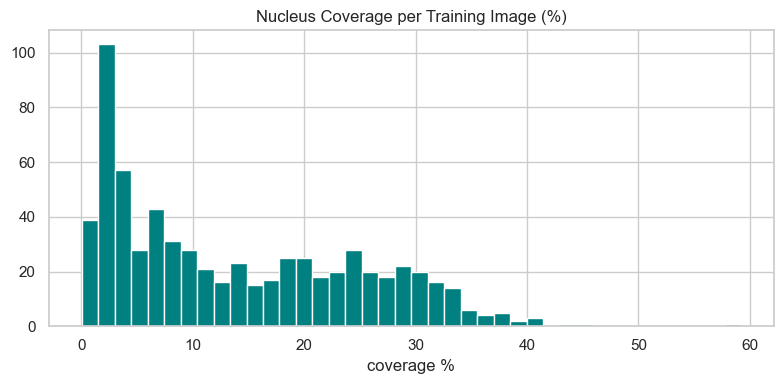

In [20]:
coverages = []
for sid in tqdm(train_ids, desc="Mask coverage"):
    img_path = next((TRAIN_DIR / sid / "images").glob("*.png"))
    w, h = Image.open(img_path).size
    total_px = w * h
    covered = np.zeros((h, w), dtype=bool)
    for mp in (TRAIN_DIR / sid / "masks").glob("*.png"):
        covered |= np.array(Image.open(mp).convert("L")) > 0
    coverages.append(covered.sum() / total_px * 100)

coverages = np.array(coverages)
print(f"Coverage  mean={coverages.mean():.1f}%  median={np.median(coverages):.1f}%  max={coverages.max():.1f}%")

plt.figure(figsize=(8, 4))
plt.hist(coverages, bins=40, color="teal", edgecolor="white")
plt.title("Nucleus Coverage per Training Image (%)"); plt.xlabel("coverage %")
plt.tight_layout()
plt.show()

## 11. Pixel Intensity Histogram (sample images)

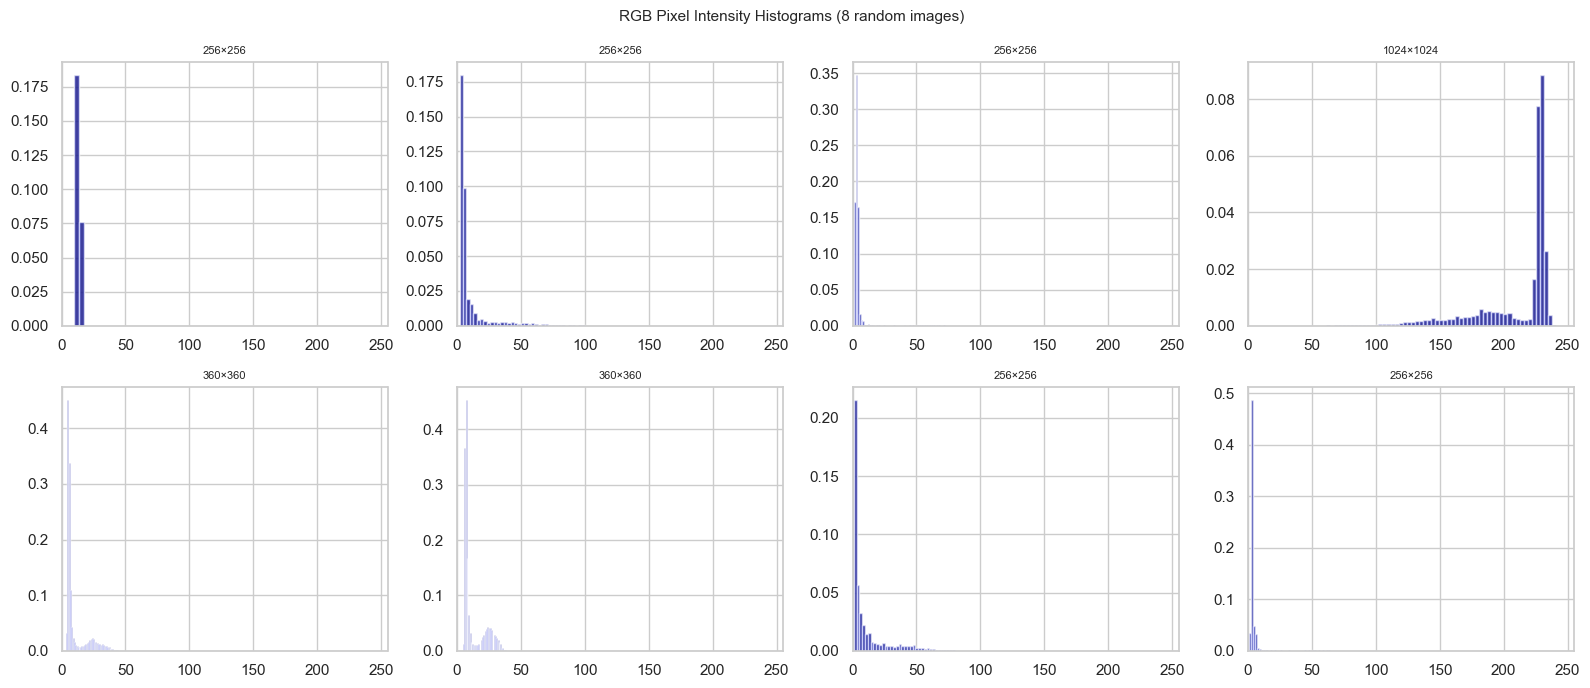

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
sample_ids_hist = random.sample(train_ids, 8)

for ax, sid in zip(axes.flatten(), sample_ids_hist):
    arr = np.array(Image.open(next((TRAIN_DIR / sid / "images").glob("*.png"))).convert("RGB"))
    for c, col in zip(range(3), ["red", "green", "blue"]):
        ax.hist(arr[:, :, c].flatten(), bins=64, alpha=0.5, color=col, density=True)
    ax.set_title(f"{arr.shape[0]}×{arr.shape[1]}", fontsize=8)
    ax.set_xlim(0, 255)

plt.suptitle("RGB Pixel Intensity Histograms (8 random images)", fontsize=11)
plt.tight_layout()
plt.show()

## 12. Test Set — Size Overview

Test metadata:   0%|          | 0/65 [00:00<?, ?it/s]

Test set sizes:
       width  height
count   65.0    65.0
mean   393.2   402.7
std    189.8   129.1
min    161.0   256.0
25%    256.0   256.0
50%    256.0   512.0
75%    640.0   519.0
max    696.0   524.0


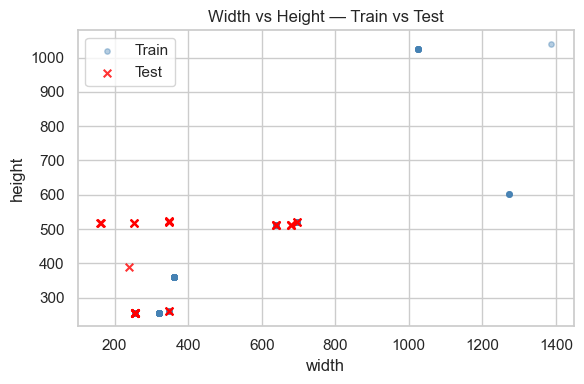

In [22]:
test_records = []
for tid in tqdm(test_ids, desc="Test metadata"):
    img_path = next((TEST_DIR / tid / "images").glob("*.png"))
    with Image.open(img_path) as img:
        w, h = img.size
        mode = img.mode
    test_records.append({"id": tid, "width": w, "height": h, "mode": mode})

df_test = pd.DataFrame(test_records)
print("Test set sizes:")
print(df_test[["width", "height"]].describe().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["width"],      df["height"],      alpha=0.4, s=15, label="Train", color="steelblue")
ax.scatter(df_test["width"], df_test["height"], alpha=0.8, s=30, label="Test",  color="red", marker="x")
ax.set_title("Width vs Height — Train vs Test")
ax.set_xlabel("width"); ax.set_ylabel("height")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Summary Statistics

In [23]:
print("=== Training Set ===")
print(f"  Images        : {len(df)}")
print(f"  Unique sizes  : {df.groupby(['width','height']).ngroups}")
print(f"  Color modes   : {dict(df['mode'].value_counts())}")
print(f"  Grayscale     : {df['is_grayscale'].sum()} ({df['is_grayscale'].mean()*100:.1f}%)")
print(f"  Nuclei/image  : min={df['n_nuclei'].min()}  mean={df['n_nuclei'].mean():.1f}  max={df['n_nuclei'].max()}")
print(f"  Coverage      : mean={coverages.mean():.1f}%  max={coverages.max():.1f}%")
print()
print("=== Test Set ===")
print(f"  Images        : {len(df_test)}")
print(f"  Color modes   : {dict(df_test['mode'].value_counts())}")

=== Training Set ===
  Images        : 670
  Unique sizes  : 9
  Color modes   : {'RGBA': 670}
  Grayscale     : 562 (83.9%)
  Nuclei/image  : min=1  mean=44.0  max=375
  Coverage      : mean=13.9%  max=59.2%

=== Test Set ===
  Images        : 65
  Color modes   : {'RGBA': 37, 'RGB': 28}
